# 02 — Second-Order Physics: The Damped Oscillator

In notebook 01 the equation had a *first* derivative $\frac{dy}{dt}$. Real machinery is usually **second
order** — accelerations, not just rates. In this notebook we solve the **damped harmonic oscillator**, the
equation behind:

- a **mass on a spring** with friction,
- an **RLC electrical circuit** (inductor + resistor + capacitor),
- **vibration of a rotating machine** (turbine, pump, motor) — very relevant when monitoring energy assets.

New things you will learn:

1. How to take a **second derivative** of the network with autograd ($\frac{d^2x}{dt^2}$).
2. How to impose **two** initial conditions (position *and* velocity).
3. Why **loss weighting** matters, and the first real **difficulty** of PINNs: oscillatory solutions.

## 1. The equation

$$m\,\frac{d^2x}{dt^2} \;+\; c\,\frac{dx}{dt} \;+\; k\,x \;=\; 0,
\qquad x(0)=x_0,\quad \frac{dx}{dt}(0)=v_0$$

- $m$ = mass (or inductance), $c$ = damping (resistance/friction), $k$ = stiffness (1/capacitance).
- The three terms are **inertia**, **damping**, and **restoring force**. Their balance produces a decaying wobble.

Because it is second order, it needs **two** initial conditions: where you start ($x_0$) *and* how fast you
start ($v_0$). Intuitively: to predict a swing you must know both its position and its push.

For the *underdamped* case (light damping) there is again an exact solution we will check against:

$$x(t)=e^{-\zeta\omega_0 t}\Big[x_0\cos(\omega_d t)+\tfrac{v_0+\zeta\omega_0 x_0}{\omega_d}\sin(\omega_d t)\Big]$$

with natural frequency $\omega_0=\sqrt{k/m}$, damping ratio $\zeta=\tfrac{c}{2\sqrt{mk}}$, and damped
frequency $\omega_d=\omega_0\sqrt{1-\zeta^2}$. (We only use this to grade the PINN.)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")

# --- physical parameters (a nicely underdamped system) ---
# TRY THIS NOTEBOOK WITH DIFFERENT VALUES OF k: 4.00 or 25.00
m, c, k = 1.0, 0.6, 25.0
x0, v0  = 1.0, 0.0          # start at position 1, at rest
T = 8.0                     # time window [0, T] seconds

omega0 = np.sqrt(k/m)
zeta   = c/(2*np.sqrt(m*k))
omega_d = omega0*np.sqrt(1-zeta**2)
print(f"natural freq w0={omega0:.3f} rad/s | damping ratio zeta={zeta:.3f} (underdamped if <1) | ~{omega_d*T/(2*np.pi):.1f} oscillations in window")

natural freq w0=5.000 rad/s | damping ratio zeta=0.060 (underdamped if <1) | ~6.4 oscillations in window


## 2. Second derivatives with autograd

To get $\frac{d^2x}{dt^2}$ we simply differentiate **twice**: first `x -> dx/dt`, then `dx/dt -> d2x/dt2`.
This is why we passed `create_graph=True` earlier — it keeps the computational graph alive so we can
differentiate the derivative. The helper below returns `x`, `dx/dt`, and `d2x/dt2` in one shot.

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden=48, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(1, hidden), nn.Tanh()] # 1st hidden layer
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()] # N-1 hidden layers
        layers += [nn.Linear(hidden, 1)] # output layer
        self.net = nn.Sequential(*layers)
    def forward(self, t):
        return self.net(t)

# Example usage:
model = MLP().to(device)

def derivatives(t, model):
    # returns x, dx/dt, d2x/dt2  for the current model at points t
    x = model(t)
    dx = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    d2x = torch.autograd.grad(dx, t, torch.ones_like(dx), create_graph=True)[0]
    return x, dx, d2x

## 3. Residual and losses

The physics residual is the equation moved to one side:

$$r(t) = m\,\ddot{x} + c\,\dot{x} + k\,x \;\stackrel{!}{=}\; 0.$$

Now we have **three** loss terms:

1. **Physics** $r(t)^2$ on collocation points,
2. **Position IC** $(x(0)-x_0)^2$,
3. **Velocity IC** $(\dot{x}(0)-v_0)^2$.

> **New idea — loss weighting.** These terms have different scales and importances. If the physics term
> dominates, the network may satisfy the equation but drift from the correct start (remember: physics gives
> the shape, ICs pick the solution). We multiply the IC terms by a weight `w_ic` so the optimizer takes them
> seriously. Tuning these weights is a normal part of PINN practice.

In [23]:
N_coll = 400
t_coll = (torch.rand(N_coll, 1, device=device) * T).requires_grad_(True) # random points in [0, T] for collocation
t_ic   = torch.zeros(1, 1, device=device, requires_grad=True) # initial condition at t=0

w_ic = 20.0   # weight on the initial-condition terms

def compute_loss():
    x, dx, d2x = derivatives(t_coll, model)
    r  = m*d2x + c*dx + k*x
    loss_phys = torch.mean(r**2)

    x_ic, dx_ic, _ = derivatives(t_ic, model)
    loss_pos = (x_ic - x0)**2
    loss_vel = (dx_ic - v0)**2

    loss = loss_phys + w_ic*(loss_pos + loss_vel).mean()
    return loss, loss_phys, loss_pos.mean(), loss_vel.mean()

## 4. Train

Oscillatory solutions are genuinely harder than the smooth decay of notebook 01, so we train a bit longer and
use a learning-rate schedule (start faster, then slow down to polish). Still only ~15 seconds on CPU.

In [24]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4000, gamma=0.5)

history = []
for it in range(12001):
    optimizer.zero_grad()
    loss, lp, lpos, lvel = compute_loss()
    loss.backward()
    optimizer.step(); scheduler.step()
    history.append(loss.item())
    if it % 1000 == 0:
        print(f"iter {it:5d} | total {loss.item():.3e} | phys {lp.item():.3e} | pos {lpos.item():.3e} | vel {lvel.item():.3e}")

iter     0 | total 7.471e+01 | phys 6.462e+01 | pos 5.026e-01 | vel 2.089e-03
iter  1000 | total 1.405e+00 | phys 1.295e+00 | pos 5.482e-03 | vel 5.063e-06
iter  2000 | total 1.435e+00 | phys 1.335e+00 | pos 3.485e-03 | vel 1.499e-03
iter  3000 | total 9.954e-01 | phys 9.413e-01 | pos 2.699e-03 | vel 1.571e-06
iter  4000 | total 5.579e-01 | phys 5.405e-01 | pos 8.687e-04 | vel 7.469e-08
iter  5000 | total 4.321e-01 | phys 4.208e-01 | pos 5.619e-04 | vel 2.021e-07
iter  6000 | total 4.062e-01 | phys 3.977e-01 | pos 4.282e-04 | vel 4.363e-08
iter  7000 | total 3.963e-01 | phys 3.883e-01 | pos 3.987e-04 | vel 1.713e-08
iter  8000 | total 3.854e-01 | phys 3.777e-01 | pos 3.810e-04 | vel 1.190e-08
iter  9000 | total 3.726e-01 | phys 3.655e-01 | pos 3.559e-04 | vel 8.111e-09
iter 10000 | total 3.524e-01 | phys 3.457e-01 | pos 3.306e-04 | vel 2.208e-09
iter 11000 | total 3.328e-01 | phys 3.267e-01 | pos 3.049e-04 | vel 1.987e-07
iter 12000 | total 3.205e-01 | phys 3.151e-01 | pos 2.703e-04 | 

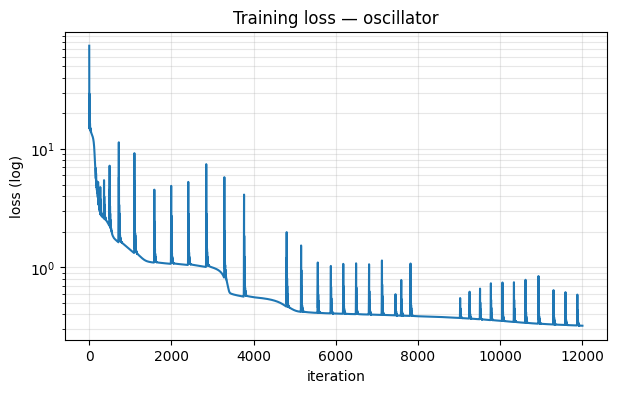

In [25]:
plt.figure(figsize=(7,4))
plt.semilogy(history); plt.xlabel("iteration"); plt.ylabel("loss (log)")
plt.title("Training loss — oscillator"); plt.grid(True, which="both", alpha=0.3); plt.show()

## 5. Compare with the exact solution

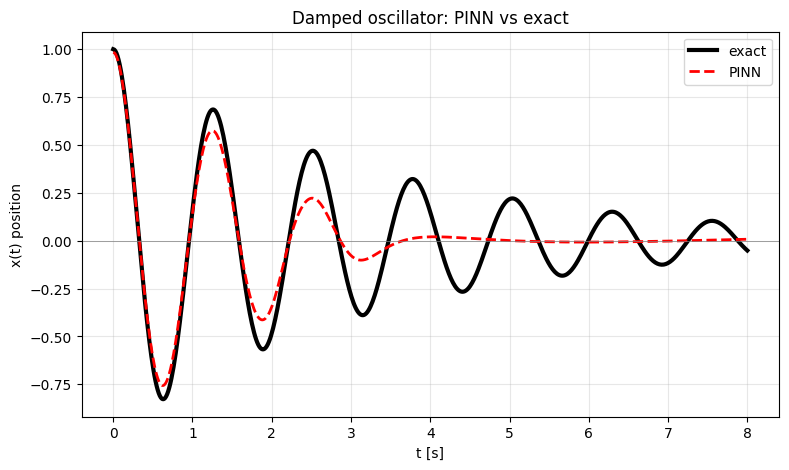

max abs error: 0.3103197821916213


In [26]:
def exact(t):
    return np.exp(-zeta*omega0*t) * (x0*np.cos(omega_d*t) + (v0+zeta*omega0*x0)/omega_d*np.sin(omega_d*t))

t_test = torch.linspace(0, T, 600, device=device).reshape(-1,1)
with torch.no_grad():
    x_pinn = model(t_test).cpu().numpy().flatten()
tt = t_test.cpu().numpy().flatten()
x_ex = exact(tt)

plt.figure(figsize=(9,5))
plt.plot(tt, x_ex, "k-", lw=3, label="exact")
plt.plot(tt, x_pinn, "r--", lw=2, label="PINN")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("t [s]"); plt.ylabel("x(t) position")
plt.title("Damped oscillator: PINN vs exact"); plt.legend(); plt.grid(alpha=0.3); plt.show()

print("max abs error:", np.max(np.abs(x_pinn - x_ex)))

## 6. The honest caveat — PINNs and oscillations

Notice this took more iterations and a bigger network than notebook 01. That is not an accident.

Neural networks have a well-documented **spectral bias**: they learn *smooth, low-frequency* shapes easily and
*wiggly, high-frequency* ones slowly. An oscillator is exactly a wiggly, high-frequency target. If you crank up
`omega0` (stiffer spring, higher `k`) or extend `T` to many oscillations, a vanilla PINN will struggle and may
fail. This is one of the most important practical lessons about PINNs:

> **PINNs are excellent for smooth, diffusion-like problems and can be fragile for highly oscillatory,
> long-horizon, or sharp-front problems.** Practitioners fix this with tricks: time-domain decomposition
> (solve short windows and stitch), Fourier feature inputs, causal/curriculum training, and better loss
> weighting. Knowing *where PINNs are weak* is exactly the kind of judgement an energy company wants.

Try it: set `k = 25.0` (so `omega0 = 5`) and rerun. Watch the fit degrade — then you understand the frontier.

## 7. Recap

- Second-order equations need the network differentiated **twice** and **two** initial conditions.
- **Loss weighting** balances competing objectives (physics vs. initial conditions).
- PINNs have a **spectral bias**: smooth good, oscillatory hard. This shapes *which* energy problems suit them.

**Next (03):** we jump from ODEs (functions of time only) to a **PDE** — the 1D heat equation, a function of
*both space and time*. This is the workhorse of thermal engineering and the gateway to real energy problems.